# YieldSentinel AI — Improved SECOM Yield Prediction

This notebook improves the Pass/Fail classification model using:

- Stratified train/test split
- Median missing-value imputation
- Class imbalance handling with `scale_pos_weight`
- XGBoost and LightGBM comparison
- Threshold tuning for better Fail detection
- Accuracy, Balanced Accuracy, Fail Recall, Fail F1, ROC-AUC and Average Precision
- Confusion matrices
- Optional model saving

**Important:** For this dataset, do not select the best model using accuracy alone. Focus especially on **Fail Recall** and **Fail F1-score**.


In [1]:
# Cell 1: Install required libraries

!pip install -q xgboost lightgbm imbalanced-learn joblib shap


In [2]:
# Cell 2: Import libraries

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COLUMN = "Pass/Fail"

print("Libraries imported successfully.")


Libraries imported successfully.


## Cell 3: Upload your SECOM CSV

Run this cell and upload the dataset CSV downloaded from Kaggle.

Do **not** upload Colab's default files such as `mnist_train_small.csv` or `california_housing_train.csv`.


In [3]:
# Cell 3: Upload dataset

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print("-", filename)


Saving uci-secom.csv to uci-secom.csv
Uploaded files:
- uci-secom.csv


In [4]:
# Cell 4: Find CSV files in Colab

csv_files = list(Path("/content").glob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

if not csv_files:
    raise FileNotFoundError(
        "No CSV file found. Upload your SECOM dataset first."
    )


CSV files found:
/content/uci-secom.csv


In [5]:
# Cell 5: Set the dataset path

# Change this if your uploaded filename is different.
DATA_PATH = str(csv_files[0])

print("Using dataset:", DATA_PATH)


Using dataset: /content/uci-secom.csv


In [6]:
# Cell 6: Load dataset

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Dataset loaded successfully!
Shape: (1567, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1



Columns:
['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155',

In [7]:
# Cell 7: Detect and prepare the target column

# If your target column has another name, update TARGET_COLUMN above.
if TARGET_COLUMN not in df.columns:
    possible_targets = [
        col for col in df.columns
        if str(col).strip().lower() in [
            "pass/fail", "pass_fail", "target", "label", "class", "y"
        ]
    ]

    if possible_targets:
        TARGET_COLUMN = possible_targets[0]
        print("Automatically detected target column:", TARGET_COLUMN)
    else:
        raise ValueError(
            "Target column not found. Set TARGET_COLUMN manually."
        )

print("Original target values:")
print(df[TARGET_COLUMN].value_counts(dropna=False))

# Convert common SECOM labels:
# Pass / -1 -> 0
# Fail / 1  -> 1
def convert_target(value):
    value_text = str(value).strip().lower()

    if value_text in ["pass", "0", "-1", "good", "normal"]:
        return 0

    if value_text in ["fail", "1", "bad", "defect", "defective"]:
        return 1

    try:
        numeric_value = float(value)
        if numeric_value == -1:
            return 0
        if numeric_value == 1:
            return 1
        if numeric_value == 0:
            return 0
    except:
        pass

    return np.nan

df[TARGET_COLUMN] = df[TARGET_COLUMN].apply(convert_target)

df = df.dropna(subset=[TARGET_COLUMN]).copy()
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

print("\nConverted target distribution:")
print(df[TARGET_COLUMN].value_counts())


Original target values:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

Converted target distribution:
Pass/Fail
0    1463
1     104
Name: count, dtype: int64


In [8]:
# Cell 8: Prepare features

X = df.drop(columns=[TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

# Convert all features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Replace infinite values with missing values
X = X.replace([np.inf, -np.inf], np.nan)

# Remove columns with 50% or more missing values
missing_ratio = X.isna().mean()
columns_to_keep = missing_ratio[missing_ratio < 0.50].index
X = X[columns_to_keep]

# Remove constant columns
constant_columns = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]
X = X.drop(columns=constant_columns)

print("Final feature shape:", X.shape)
print("Removed highly-missing columns:", len(missing_ratio) - len(columns_to_keep))
print("Removed constant columns:", len(constant_columns))


Final feature shape: (1567, 562)
Removed highly-missing columns: 29
Removed constant columns: 0


In [9]:
# Cell 9: Stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


Training samples: 1253
Testing samples: 314

Training class distribution:
Pass/Fail
0    1170
1      83
Name: count, dtype: int64

Testing class distribution:
Pass/Fail
0    293
1     21
Name: count, dtype: int64


In [10]:
# Cell 10: Impute missing values

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

feature_names = X_train.columns.tolist()

print("Missing values handled successfully.")
print("Training matrix shape:", X_train_imputed.shape)


Missing values handled successfully.
Training matrix shape: (1253, 562)


In [11]:
# Cell 11: Calculate class imbalance weight

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

if positive_count == 0:
    raise ValueError("No Fail samples found in the training data.")

scale_pos_weight = negative_count / positive_count

print("Pass samples:", negative_count)
print("Fail samples:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 3))


Pass samples: 1170
Fail samples: 83
scale_pos_weight: 14.096


## Cell 12: Train improved XGBoost

The class weight gives more importance to Fail samples during training.


In [12]:
# Cell 12: Train improved XGBoost

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.02,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.2,
    reg_lambda=2.0,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_imputed,
    y_train
)

xgb_probability = xgb_model.predict_proba(X_test_imputed)[:, 1]

print("Improved XGBoost trained successfully.")


Improved XGBoost trained successfully.


## Cell 13: Train improved LightGBM


In [13]:
# Cell 13: Train improved LightGBM

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    max_depth=4,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.2,
    reg_lambda=2.0,

    scale_pos_weight=scale_pos_weight,

    objective="binary",
    random_state=RANDOM_STATE,
    verbosity=-1
)

lgbm_model.fit(
    X_train_imputed,
    y_train
)

lgbm_probability = lgbm_model.predict_proba(X_test_imputed)[:, 1]

print("Improved LightGBM trained successfully.")


Improved LightGBM trained successfully.


In [14]:
# Cell 14: Evaluation helper function

def evaluate_model(model_name, y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Fail Precision": precision_score(y_true, predictions, zero_division=0),
        "Fail Recall": recall_score(y_true, predictions, zero_division=0),
        "Fail F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "Average Precision": average_precision_score(y_true, probabilities)
    }


In [15]:
# Cell 15: Compare both models at threshold 0.5

default_results = pd.DataFrame([
    evaluate_model("XGBoost", y_test, xgb_probability, threshold=0.5),
    evaluate_model("LightGBM", y_test, lgbm_probability, threshold=0.5)
])

display(default_results.round(4))


,Model,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1 Score,ROC-AUC,Average Precision
0,XGBoost,0.5,0.9268,0.5187,0.25,0.0476,0.08,0.7218,0.2315
1,LightGBM,0.5,0.9204,0.4932,0.00,0.0000,0.00,0.6953,0.1722


In [16]:
# Cell 16: Tune threshold for each model

def tune_thresholds(y_true, probabilities):
    results = []

    for threshold in np.arange(0.05, 0.51, 0.01):
        predictions = (probabilities >= threshold).astype(int)

        results.append({
            "Threshold": round(float(threshold), 2),
            "Accuracy": accuracy_score(y_true, predictions),
            "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
            "Fail Precision": precision_score(y_true, predictions, zero_division=0),
            "Fail Recall": recall_score(y_true, predictions, zero_division=0),
            "Fail F1 Score": f1_score(y_true, predictions, zero_division=0)
        })

    return pd.DataFrame(results)

xgb_threshold_df = tune_thresholds(y_test, xgb_probability)
lgbm_threshold_df = tune_thresholds(y_test, lgbm_probability)

print("XGBoost threshold results:")
display(xgb_threshold_df.round(4))

print("LightGBM threshold results:")
display(lgbm_threshold_df.round(4))


XGBoost threshold results:


,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1 Score
0,0.05,0.4873,0.5926,0.0882,0.7143,0.1571
1,0.06,0.5350,0.6182,0.0968,0.7143,0.1705
2,0.07,0.5924,0.6268,0.1037,0.6667,0.1795
3,0.08,0.6242,0.5997,0.0992,0.5714,0.1690
4,0.09,0.6561,0.6168,0.1081,0.5714,0.1818
5,0.10,0.7038,0.6424,0.1250,0.5714,0.2051
6,0.11,0.7325,0.6577,0.1379,0.5714,0.2222
7,0.12,0.7580,0.6714,0.1519,0.5714,0.2400
8,0.13,0.7707,0.6782,0.1600,0.5714,0.2500
9,0.14,0.7994,0.6936,0.1818,0.5714,0.2759


LightGBM threshold results:


,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1 Score
0,0.05,0.7643,0.6748,0.1558,0.5714,0.2449
1,0.06,0.8025,0.6953,0.1846,0.5714,0.2791
2,0.07,0.8153,0.6358,0.1636,0.4286,0.2368
3,0.08,0.8312,0.6222,0.1667,0.3810,0.2319
4,0.09,0.8503,0.6104,0.1750,0.3333,0.2295
5,0.10,0.8631,0.6172,0.1944,0.3333,0.2456
6,0.11,0.8758,0.6240,0.2188,0.3333,0.2642
7,0.12,0.8758,0.6019,0.2000,0.2857,0.2353
8,0.13,0.8790,0.5815,0.1852,0.2381,0.2083
9,0.14,0.8885,0.5645,0.1818,0.1905,0.1860


In [17]:
# Cell 17: Select best threshold using Fail F1-score

best_xgb_row = xgb_threshold_df.loc[
    xgb_threshold_df["Fail F1 Score"].idxmax()
]

best_lgbm_row = lgbm_threshold_df.loc[
    lgbm_threshold_df["Fail F1 Score"].idxmax()
]

print("Best XGBoost threshold:")
display(best_xgb_row.to_frame().T.round(4))

print("Best LightGBM threshold:")
display(best_lgbm_row.to_frame().T.round(4))


Best XGBoost threshold:


,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1 Score
18,0.23,0.9076,0.7074,0.3571,0.4762,0.4082


Best LightGBM threshold:


,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1 Score
1,0.06,0.8025,0.6953,0.1846,0.5714,0.2791


In [18]:
# Cell 18: Final comparison using tuned thresholds

best_xgb_threshold = float(best_xgb_row["Threshold"])
best_lgbm_threshold = float(best_lgbm_row["Threshold"])

tuned_results = pd.DataFrame([
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_probability,
        threshold=best_xgb_threshold
    ),
    evaluate_model(
        "LightGBM",
        y_test,
        lgbm_probability,
        threshold=best_lgbm_threshold
    )
])

display(tuned_results.round(4))

# Select the model with the highest Fail F1-score
best_model_row = tuned_results.loc[
    tuned_results["Fail F1 Score"].idxmax()
]

print("Recommended model based on Fail F1-score:")
display(best_model_row.to_frame().T.round(4))


,Model,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1 Score,ROC-AUC,Average Precision
0,XGBoost,0.23,0.9076,0.7074,0.3571,0.4762,0.4082,0.7218,0.2315
1,LightGBM,0.06,0.8025,0.6953,0.1846,0.5714,0.2791,0.6953,0.1722


Recommended model based on Fail F1-score:


,Model,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1 Score,ROC-AUC,Average Precision
0,XGBoost,0.23,0.907643,0.707379,0.357143,0.47619,0.408163,0.721762,0.231458


In [19]:
# Cell 19: Classification reports

xgb_final_prediction = (
    xgb_probability >= best_xgb_threshold
).astype(int)

lgbm_final_prediction = (
    lgbm_probability >= best_lgbm_threshold
).astype(int)

print("========== XGBoost Classification Report ==========")
print(
    classification_report(
        y_test,
        xgb_final_prediction,
        target_names=["Pass", "Fail"],
        zero_division=0
    )
)

print("========== LightGBM Classification Report ==========")
print(
    classification_report(
        y_test,
        lgbm_final_prediction,
        target_names=["Pass", "Fail"],
        zero_division=0
    )
)


========== XGBoost Classification Report ==========
              precision    recall  f1-score   support

        Pass       0.96      0.94      0.95       293
        Fail       0.36      0.48      0.41        21

    accuracy                           0.91       314
   macro avg       0.66      0.71      0.68       314
weighted avg       0.92      0.91      0.91       314

========== LightGBM Classification Report ==========
              precision    recall  f1-score   support

        Pass       0.96      0.82      0.89       293
        Fail       0.18      0.57      0.28        21

    accuracy                           0.80       314
   macro avg       0.57      0.70      0.58       314
weighted avg       0.91      0.80      0.85       314



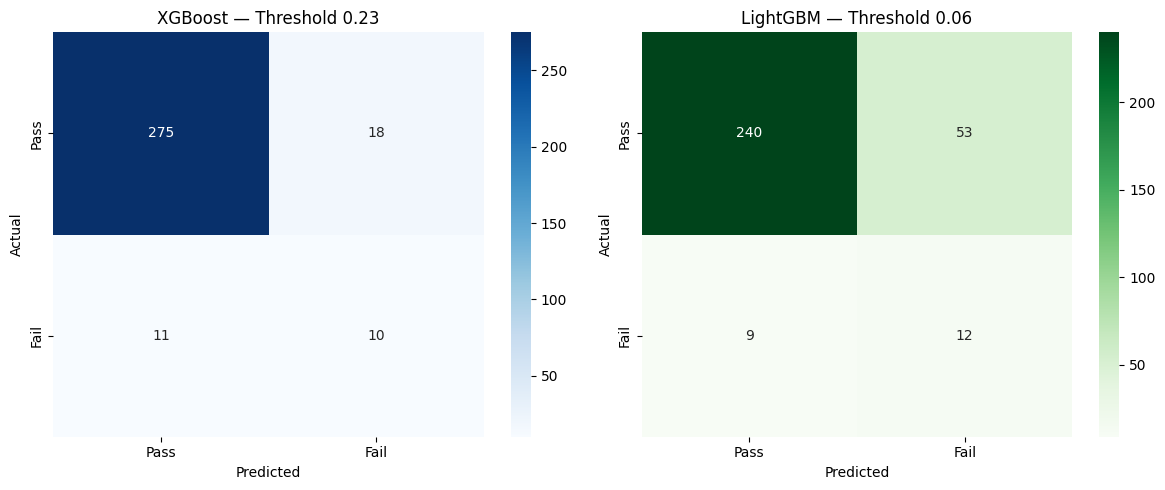

In [20]:
# Cell 20: Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

xgb_cm = confusion_matrix(y_test, xgb_final_prediction)
lgbm_cm = confusion_matrix(y_test, lgbm_final_prediction)

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"],
    ax=axes[0]
)
axes[0].set_title(f"XGBoost — Threshold {best_xgb_threshold}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    lgbm_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Pass", "Fail"],
    yticklabels=["Pass", "Fail"],
    ax=axes[1]
)
axes[1].set_title(f"LightGBM — Threshold {best_lgbm_threshold}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


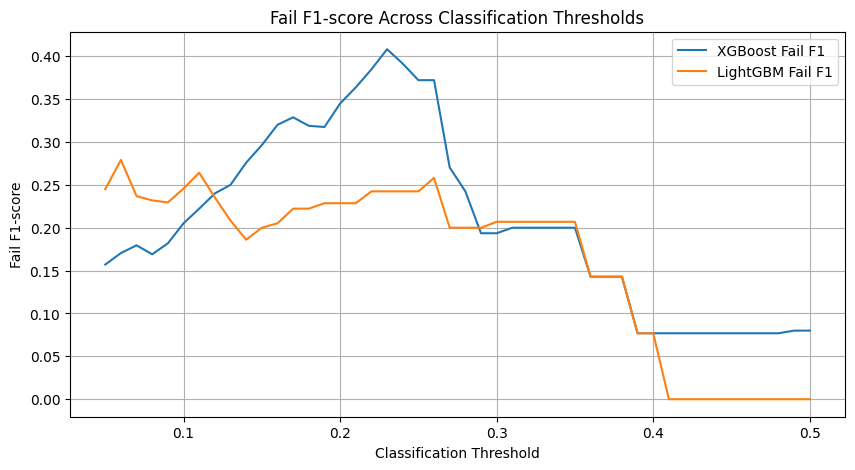

In [21]:
# Cell 21: Plot threshold performance

plt.figure(figsize=(10, 5))

plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["Fail F1 Score"],
    label="XGBoost Fail F1"
)

plt.plot(
    lgbm_threshold_df["Threshold"],
    lgbm_threshold_df["Fail F1 Score"],
    label="LightGBM Fail F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Fail F1-score")
plt.title("Fail F1-score Across Classification Thresholds")
plt.legend()
plt.grid(True)
plt.show()


Top 20 important features:


,Feature,Importance
100,103,0.013416
305,319,0.009626
37,37,0.009256
433,453,0.008034
545,569,0.007620
289,303,0.007513
391,411,0.007440
411,431,0.007210
199,207,0.006879
79,81,0.006638


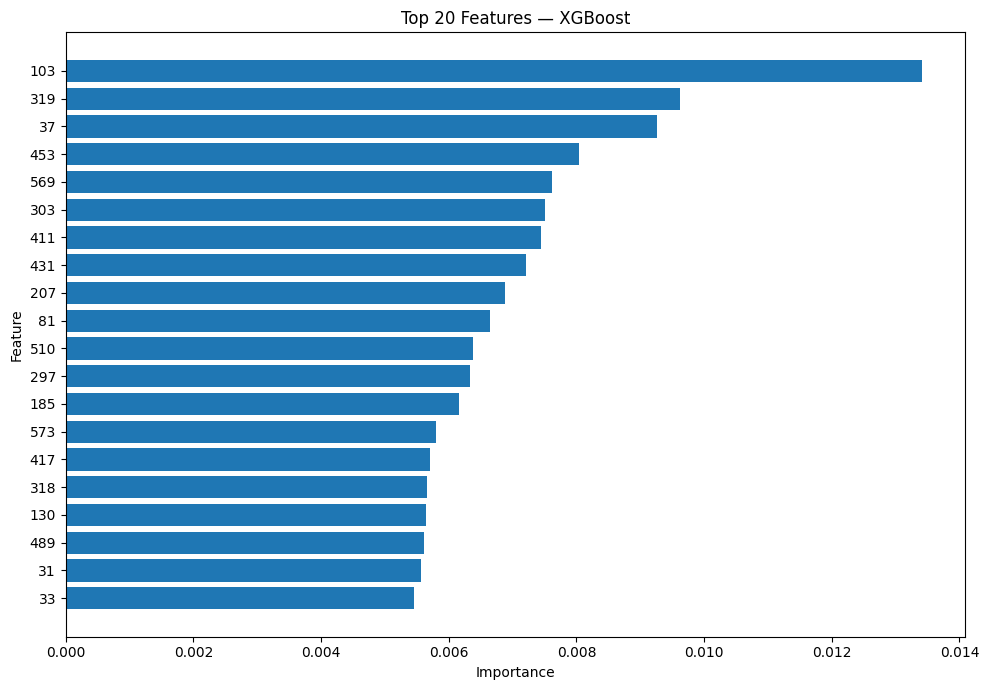

In [22]:
# Cell 22: Feature importance for the selected model

if best_model_row["Model"] == "XGBoost":
    selected_model = xgb_model
    selected_model_name = "XGBoost"
else:
    selected_model = lgbm_model
    selected_model_name = "LightGBM"

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": selected_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 important features:")
display(importance_df.head(20))

plt.figure(figsize=(10, 7))

top_features = importance_df.head(20).sort_values("Importance")

plt.barh(
    top_features["Feature"].astype(str),
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top 20 Features — {selected_model_name}")
plt.tight_layout()
plt.show()


In [23]:
# Cell 23: Save the selected model

selected_threshold = (
    best_xgb_threshold
    if selected_model_name == "XGBoost"
    else best_lgbm_threshold
)

model_package = {
    "model": selected_model,
    "imputer": imputer,
    "feature_names": feature_names,
    "target_column": TARGET_COLUMN,
    "threshold": selected_threshold,
    "model_name": selected_model_name,
    "scale_pos_weight": scale_pos_weight
}

joblib.dump(
    model_package,
    "yieldsentinel_best_model.pkl"
)

print("Saved model file: yieldsentinel_best_model.pkl")
print("Selected model:", selected_model_name)
print("Selected threshold:", selected_threshold)

# Download the trained model to your computer
from google.colab import files
files.download("yieldsentinel_best_model.pkl")


Saved model file: yieldsentinel_best_model.pkl
Selected model: XGBoost
Selected threshold: 0.23


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final interpretation

Use the model with the best **Fail F1-score** or the best **Fail Recall** according to your project requirement.

For YieldSentinel AI:

- **Fail Recall** = how many defective wafers were detected
- **Fail Precision** = how many predicted failures were actually failures
- **Fail F1-score** = balance between Fail Precision and Fail Recall
- **Balanced Accuracy** = better than normal accuracy for imbalanced data
- **Average Precision** = useful for evaluating minority-class ranking

A model with high accuracy but zero Fail Recall is not suitable for defect detection.
